In [3]:
import pandas as pd

In [4]:
customers = pd.read_csv('../data/olist_customers_dataset.csv')
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
orders = pd.read_csv('../data/olist_orders_dataset.csv')
orders.head() 

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
order_items.head() 

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [7]:
print(customers.shape)
print(orders.shape)
print(order_items.shape) 

(99441, 5)
(99441, 8)
(112650, 7)


In [8]:
df = orders.merge(order_items, on='order_id', how='inner') 

In [9]:
df = df.merge(customers, on='customer_id', how='inner') 

In [10]:
print(df.shape)
df.head() 

(112650, 18)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [11]:
print(df.isnull().sum()) 

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
dtype: int64


In [12]:
df = df[df['order_status'] == 'delivered'] 

In [13]:
df = df.dropna(subset=['order_purchase_timestamp'])
df = df[df['price'] > 0] 

In [14]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp']) 

In [15]:
print(f"Base final: {df.shape[0]} linhas | {df['customer_unique_id'].nunique()} clientes únicos") 

Base final: 110197 linhas | 93358 clientes únicos


In [16]:
import datetime as dt
data_referencia = df['order_purchase_timestamp'].max() + dt.timedelta(days=1) 

In [17]:
print(f"Data de referência: {data_referencia.date()}") 

Data de referência: 2018-08-30


In [18]:
rfm = df.groupby('customer_unique_id').agg( Recencia=('order_purchase_timestamp', lambda x: (data_referencia - x.max()).days), Frequencia=('order_id', 'nunique'), Monetario=('price', 'sum') ).reset_index() 

In [19]:
rfm.head(10) 

,customer_unique_id,Recencia,Frequencia,Monetario
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
2,0000f46a3911fa3c0805444483337064,537,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00
5,0004bd2a26a76fe21f786e4fbd80607f,146,1,154.00
6,00050ab1314c0e55a6ca13cf7181fecf,132,1,27.99
7,00053a61a98854899e70ed204dd4bafe,183,1,382.00
8,0005e1862207bf6ccc02e4228effd9a0,543,1,135.00
9,0005ef4cd20d2893f0d9fbd94d3c0d97,170,1,104.90


In [20]:
rfm.describe() 

,Recencia,Frequencia,Monetario
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,141.621480
std,152.591453,0.209097,215.694014
min,1.000000,1.000000,0.850000
25%,114.000000,1.000000,47.650000
50%,219.000000,1.000000,89.730000
75%,346.000000,1.000000,154.737500
max,714.000000,15.000000,13440.000000


In [21]:
import matplotlib.pyplot as plt 
import seaborn as sns 

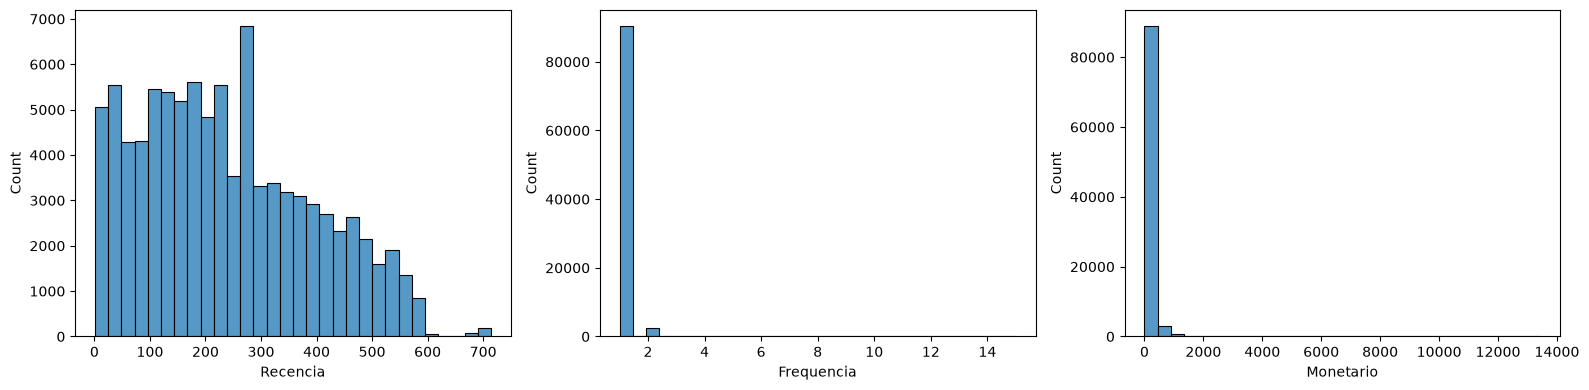

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4)); sns.histplot(rfm['Recencia'], bins=30, ax=axes[0]); sns.histplot(rfm['Frequencia'], bins=30, ax=axes[1]); sns.histplot(rfm['Monetario'], bins=30, ax=axes[2]); plt.tight_layout(); plt.show() 

In [23]:
rfm['Frequencia'].value_counts().head(10) 

Frequencia
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

In [24]:
rfm['R_score'] = pd.qcut(rfm['Recencia'], 4, labels=[4,3,2,1]).astype(int) 

In [25]:
rfm['M_score'] = pd.qcut(rfm['Monetario'], 4, labels=[1,2,3,4]).astype(int) 

In [26]:
def nota_frequencia(freq):
    return 1 if freq == 1 else 2 if freq == 2 else 3 if freq == 3 else 4

rfm['F_score'] = rfm['Frequencia'].apply(nota_frequencia)

 

In [27]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str) 

In [28]:
rfm['RFM_Score'].value_counts().head(10) 

RFM_Score
111    5955
212    5937
311    5886
313    5835
411    5825
112    5817
413    5765
412    5643
213    5614
312    5584
Name: count, dtype: int64

In [ ]:
from sklearn.preprocessing import StandardScaler; from sklearn.cluster import KMeans; from sklearn.metrics import silhouette_score 

In [33]:
import numpy as np 

In [34]:
rfm_log = rfm[['Recencia', 'Frequencia', 'Monetario']].apply(lambda x: np.log1p(x)) 

In [35]:
scaler = StandardScaler(); rfm_scaled = scaler.fit_transform(rfm_log) 

In [39]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette = []

for k in range(2, 8):
    km = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        n_init=3,
        batch_size=1000
    )
    labels = km.fit_predict(rfm_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(rfm_scaled, labels))
    print(f'Concluído para k={k}') 


Concluído para k=2
Concluído para k=3
Concluído para k=4
Concluído para k=5
Concluído para k=6
Concluído para k=7


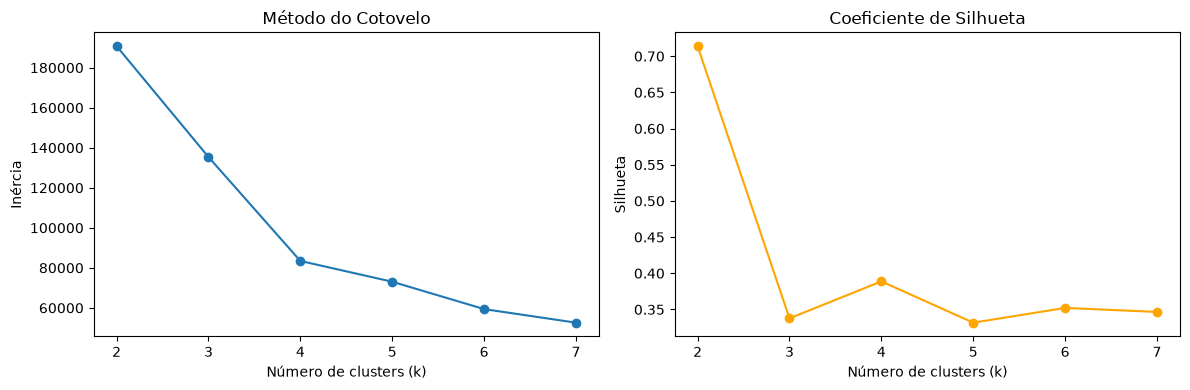

In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(2, 8), inertia, marker='o')
axes[0].set_title('Método do Cotovelo')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inércia')

axes[1].plot(range(2, 8), silhouette, marker='o', color='orange')
axes[1].set_title('Coeficiente de Silhueta')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhueta')

plt.tight_layout()
plt.show()


In [43]:
from sklearn.cluster import MiniBatchKMeans

K_FINAL = 4

kmeans = MiniBatchKMeans(
    n_clusters=K_FINAL,
    random_state=42,
    n_init=10,
    batch_size=1000
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print('Clusters criados com sucesso') 


Clusters criados com sucesso


In [44]:
rfm['Cluster'].value_counts().sort_index() 

Cluster
0    16538
1    36394
2    37625
3     2801
Name: count, dtype: int64

In [45]:
resumo_clusters = rfm.groupby('Cluster').agg(
    Recencia_media=('Recencia', 'mean'),
    Frequencia_media=('Frequencia', 'mean'),
    Monetario_medio=('Monetario', 'mean'),
    Qtd_clientes=('customer_unique_id', 'count')
).round(1)

resumo_clusters['pct_base'] = (
    resumo_clusters['Qtd_clientes'] / resumo_clusters['Qtd_clientes'].sum() * 100
).round(1)

resumo_clusters = resumo_clusters.sort_values('Monetario_medio', ascending=False)

resumo_clusters


,Recencia_media,Frequencia_media,Monetario_medio,Qtd_clientes,pct_base
Cluster,,,,,
3,220.3,2.1,260.1,2801,3.0
1,274.0,1.0,243.5,36394,39.0
0,43.2,1.0,113.4,16538,17.7
2,290.0,1.0,46.7,37625,40.3


In [46]:
ranking = resumo_clusters.copy()

ranking['Recencia_rank'] = ranking['Recencia_media'].rank()
ranking['Monetario_rank'] = ranking['Monetario_medio'].rank(ascending=False)

ranking['Score_combinado'] = (
    ranking['Recencia_rank'] + ranking['Monetario_rank']
)

ranking = ranking.sort_values('Score_combinado')

ranking


,Recencia_media,Frequencia_media,Monetario_medio,Qtd_clientes,pct_base,Recencia_rank,Monetario_rank,Score_combinado
Cluster,,,,,,,,
3,220.3,2.1,260.1,2801,3.0,2.0,1.0,3.0
0,43.2,1.0,113.4,16538,17.7,1.0,3.0,4.0
1,274.0,1.0,243.5,36394,39.0,3.0,2.0,5.0
2,290.0,1.0,46.7,37625,40.3,4.0,4.0,8.0


In [48]:
nomes_ordenados = [
    'VIP / Campeões',
    'Fiéis / Regulares',
    'Novos / Em desenvolvimento',
    'Risco de Churn / Inativos'
]

mapa_nomes = {}

for i, cluster_id in enumerate(ranking.index):
    mapa_nomes[cluster_id] = nomes_ordenados[i]

print(mapa_nomes)


{3: 'VIP / Campeões', 0: 'Fiéis / Regulares', 1: 'Novos / Em desenvolvimento', 2: 'Risco de Churn / Inativos'}


In [50]:
rfm['Segmento'] = rfm['Cluster'].map(mapa_nomes) 

In [52]:
rfm[['customer_unique_id', 'Recencia', 'Frequencia', 'Monetario', 'Segmento']].head(15) 

,customer_unique_id,Recencia,Frequencia,Monetario,Segmento
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,Novos / Em desenvolvimento
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,Risco de Churn / Inativos
2,0000f46a3911fa3c0805444483337064,537,1,69.00,Risco de Churn / Inativos
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,Risco de Churn / Inativos
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,Novos / Em desenvolvimento
5,0004bd2a26a76fe21f786e4fbd80607f,146,1,154.00,Novos / Em desenvolvimento
6,00050ab1314c0e55a6ca13cf7181fecf,132,1,27.99,Risco de Churn / Inativos
7,00053a61a98854899e70ed204dd4bafe,183,1,382.00,Novos / Em desenvolvimento
8,0005e1862207bf6ccc02e4228effd9a0,543,1,135.00,Novos / Em desenvolvimento
9,0005ef4cd20d2893f0d9fbd94d3c0d97,170,1,104.90,Novos / Em desenvolvimento


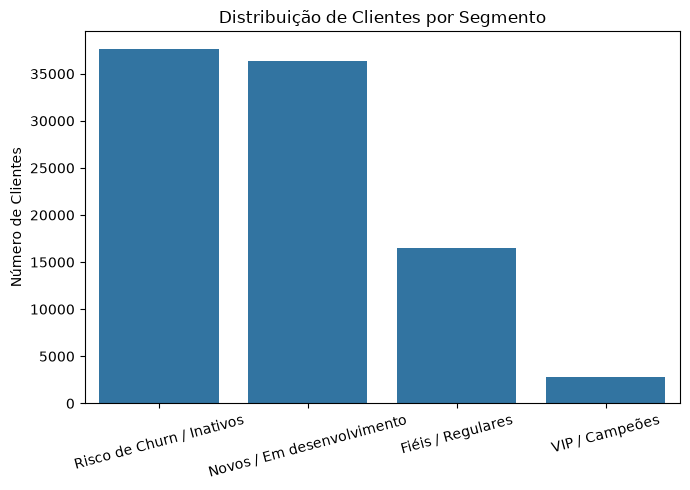

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

ordem_segmentos = rfm['Segmento'].value_counts().index

plt.figure(figsize=(7, 5))

sns.countplot(
    data=rfm,
    x='Segmento',
    order=ordem_segmentos
)

plt.title('Distribuição de Clientes por Segmento')
plt.ylabel('Número de Clientes')
plt.xlabel('')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


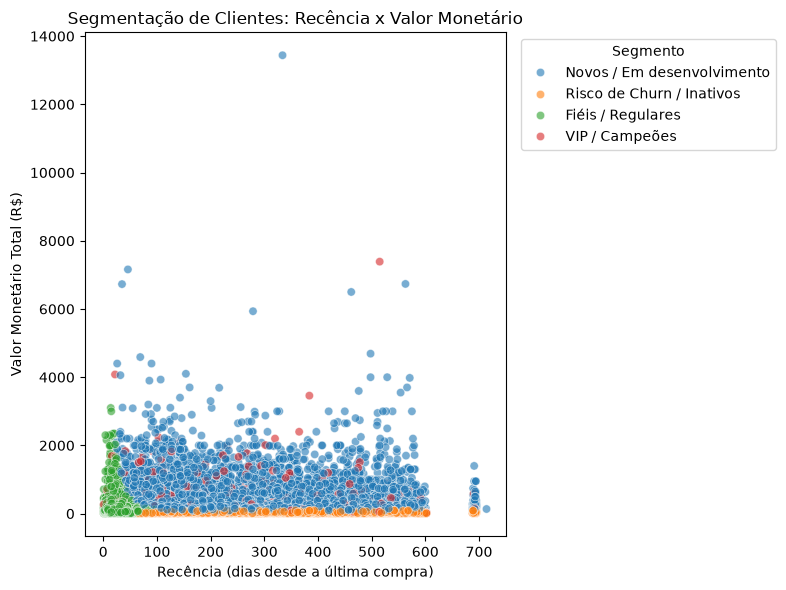

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x='Recencia',
    y='Monetario',
    hue='Segmento',
    alpha=0.6
)

plt.title('Segmentação de Clientes: Recência x Valor Monetário')
plt.xlabel('Recência (dias desde a última compra)')
plt.ylabel('Valor Monetário Total (R$)')
plt.legend(title='Segmento', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()


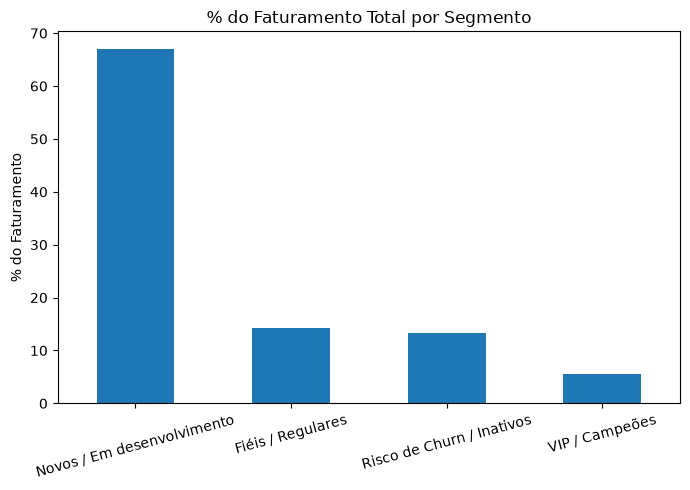

Segmento
Novos / Em desenvolvimento    67.0
Fiéis / Regulares             14.2
Risco de Churn / Inativos     13.3
VIP / Campeões                 5.5
Name: Monetario, dtype: float64


In [55]:
import matplotlib.pyplot as plt

# Calcula a receita total por segmento
receita_segmento = rfm.groupby('Segmento')['Monetario'].sum()
receita_segmento = receita_segmento.sort_values(ascending=False)

# Calcula a porcentagem de participação de cada segmento
receita_pct = (receita_segmento / receita_segmento.sum() * 100).round(1)

# Criação do gráfico
fig, ax = plt.subplots(figsize=(7, 5))
receita_pct.plot(kind='bar', ax=ax)

ax.set_title('% do Faturamento Total por Segmento')
ax.set_ylabel('% do Faturamento')
ax.set_xlabel('')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# Exibe os valores percentuais
print(receita_pct)


In [56]:
total_clientes = rfm.shape[0]
total_receita = rfm['Monetario'].sum()

print('RESUMO EXECUTIVO - SEGMENTACAO RFM')
print('=' * 50)

for segmento in ordem_segmentos:
    dados_seg = rfm[rfm['Segmento'] == segmento]
    
    qtd = dados_seg.shape[0]
    pct_clientes = qtd / total_clientes * 100
    
    receita_seg = dados_seg['Monetario'].sum()
    pct_receita = receita_seg / total_receita * 100
    
    recencia_media = dados_seg['Recencia'].mean()
    
    print('')
    print(segmento)
    print('Clientes:', qtd, '(', round(pct_clientes, 1), '% da base )')
    print('Receita: R$', round(receita_seg, 2), '(', round(pct_receita, 1), '% do total )')
    print('Recencia média:', round(recencia_media, 0), 'dias')


RESUMO EXECUTIVO - SEGMENTACAO RFM

Risco de Churn / Inativos
Clientes: 37625 ( 40.3 % da base )
Receita: R$ 1756950.69 ( 13.3 % do total )
Recencia média: 290.0 dias

Novos / Em desenvolvimento
Clientes: 36394 ( 39.0 % da base )
Receita: R$ 8860586.96 ( 67.0 % do total )
Recencia média: 274.0 dias

Fiéis / Regulares
Clientes: 16538 ( 17.7 % da base )
Receita: R$ 1875551.71 ( 14.2 % do total )
Recencia média: 43.0 dias

VIP / Campeões
Clientes: 2801 ( 3.0 % da base )
Receita: R$ 728408.75 ( 5.5 % do total )
Recencia média: 220.0 dias


In [57]:
rfm_final = rfm[
    [
        'customer_unique_id',
        'Recencia',
        'Frequencia',
        'Monetario',
        'R_score',
        'F_score',
        'M_score',
        'RFM_Score',
        'Cluster',
        'Segmento'
    ]
]

rfm_final = rfm_final.sort_values('Monetario', ascending=False)

rfm_final.to_csv('../data/clientes_segmentados_rfm.csv', index=False)
resumo_clusters.to_csv('../data/resumo_clusters.csv')

print('Arquivos exportados com sucesso na pasta data/')


Arquivos exportados com sucesso na pasta data/


In [58]:
total_clientes = rfm.shape[0]

total_receita = rfm['Monetario'].sum()

print('RESUMO EXECUTIVO - SEGMENTACAO RFM')
print('=' * 50)

for segmento in ordem_segmentos:
    dados_seg = rfm[rfm['Segmento'] == segmento]
    qtd = dados_seg.shape[0]
    pct_clientes = qtd / total_clientes * 100
    receita_seg = dados_seg['Monetario'].sum()
    pct_receita = receita_seg / total_receita * 100
    recencia_media = dados_seg['Recencia'].mean()

    print('')
    print(segmento)
    print('Clientes:', qtd, '(', round(pct_clientes, 1), '% da base )')
    print('Receita: R$', round(receita_seg, 2), '(', round(pct_receita, 1), '% do total )')
    print('Recencia media:', round(recencia_media, 0), 'dias') 

RESUMO EXECUTIVO - SEGMENTACAO RFM

Risco de Churn / Inativos
Clientes: 37625 ( 40.3 % da base )
Receita: R$ 1756950.69 ( 13.3 % do total )
Recencia media: 290.0 dias

Novos / Em desenvolvimento
Clientes: 36394 ( 39.0 % da base )
Receita: R$ 8860586.96 ( 67.0 % do total )
Recencia media: 274.0 dias

Fiéis / Regulares
Clientes: 16538 ( 17.7 % da base )
Receita: R$ 1875551.71 ( 14.2 % do total )
Recencia media: 43.0 dias

VIP / Campeões
Clientes: 2801 ( 3.0 % da base )
Receita: R$ 728408.75 ( 5.5 % do total )
Recencia media: 220.0 dias
